# SVM
Task 1: Exploratory Data Analysis (EDA)
1.	Load the dataset and perform fundamental data exploration.
2.	Utilize histograms, box plots, or density plots to understand feature distributions.
3.	Investigate feature correlations to discern relationships within the data.


In [28]:
import pandas as pd

In [29]:
#Read the dataset
df=pd.read_csv('Pharma_Industry.csv')
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [30]:
df.shape

(500, 6)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [32]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [33]:
df.duplicated().sum()

np.int64(0)

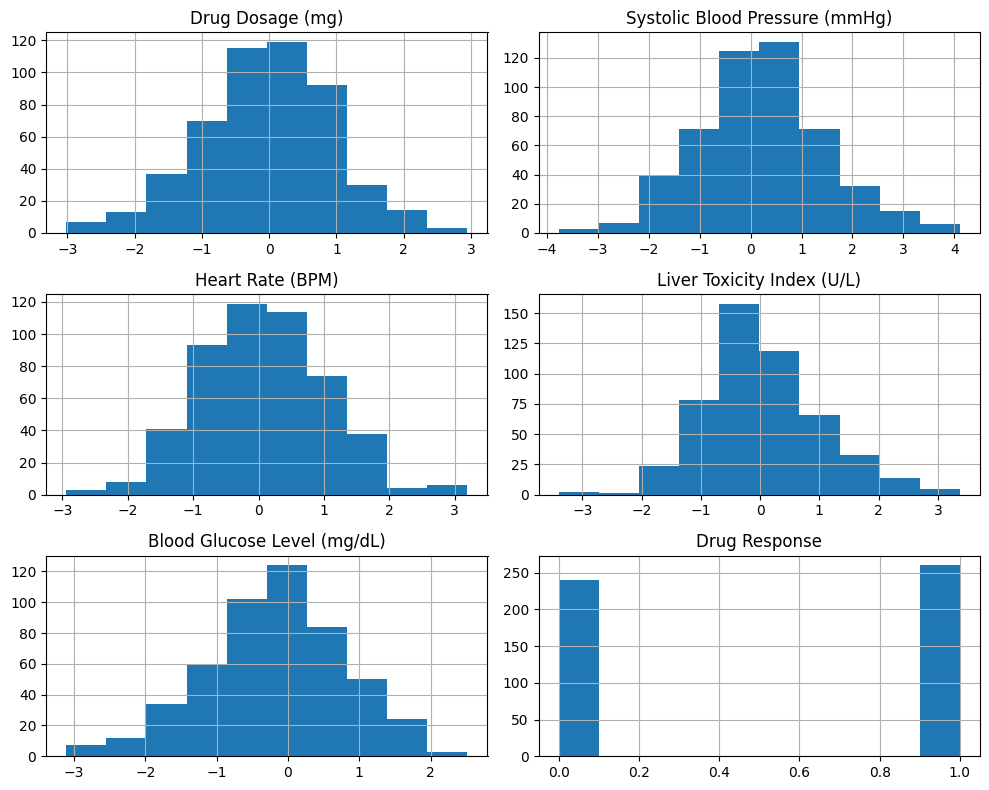

In [34]:
# perform fundamental data exploration
# 1. Distribution of all columns in a subplots
import matplotlib.pyplot as plt
import seaborn as sns
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

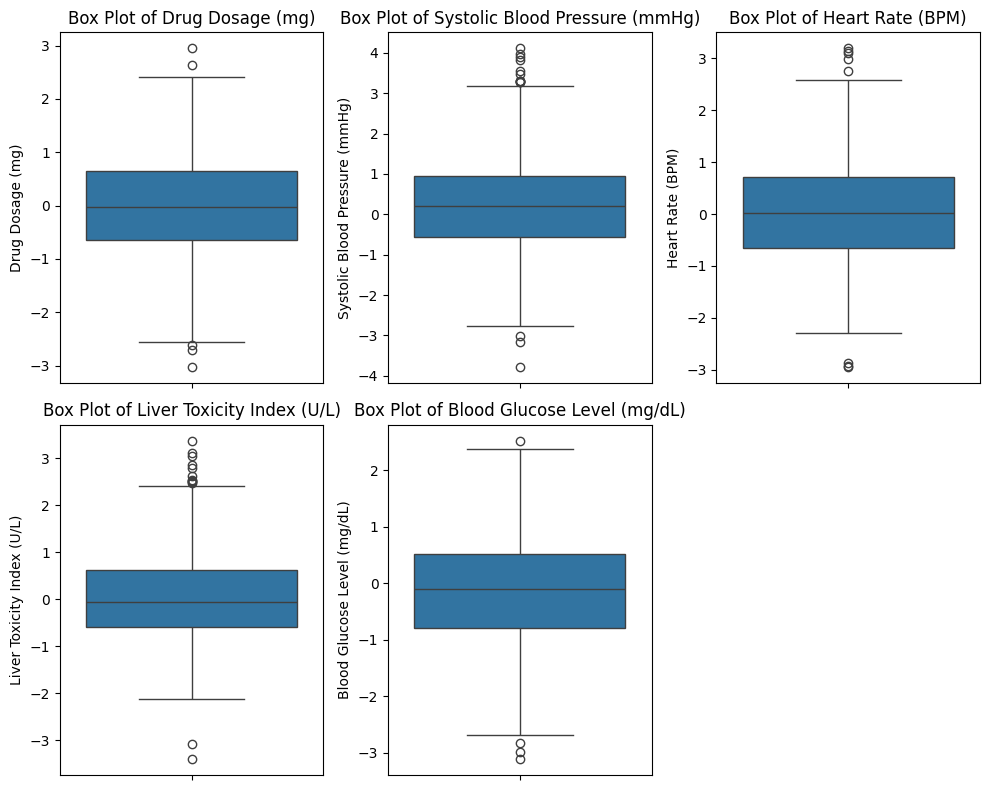

In [35]:
# box plots
plt.figure(figsize=(10, 8))
for i, column in enumerate(df.columns[:-1]):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
plt.tight_layout()
plt.show()

In [36]:
# # cap outliers using IQR method
# def cap_outliers_iqr(df, column):
#     Q1 = df[column].quantile(0.25)
#     Q3 = df[column].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR
#     df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
# for column in df.columns[:-1]:
#     cap_outliers_iqr(df, column)
# # check for outliers after capping
# plt.figure(figsize=(10, 8))
# for i, column in enumerate(df.columns[:-1]):
#     plt.subplot(2, 3, i + 1)
#     sns.boxplot(y=df[column])
#     plt.title(f'Box Plot of {column} after capping')
# plt.tight_layout()
# plt.show()

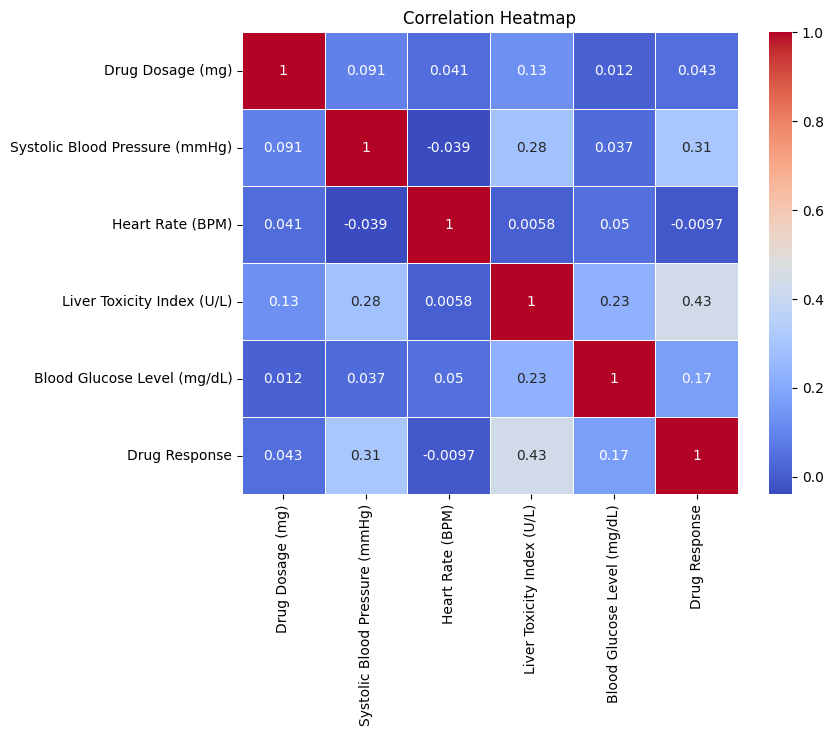

In [37]:
# 2. Correlation between the columns
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

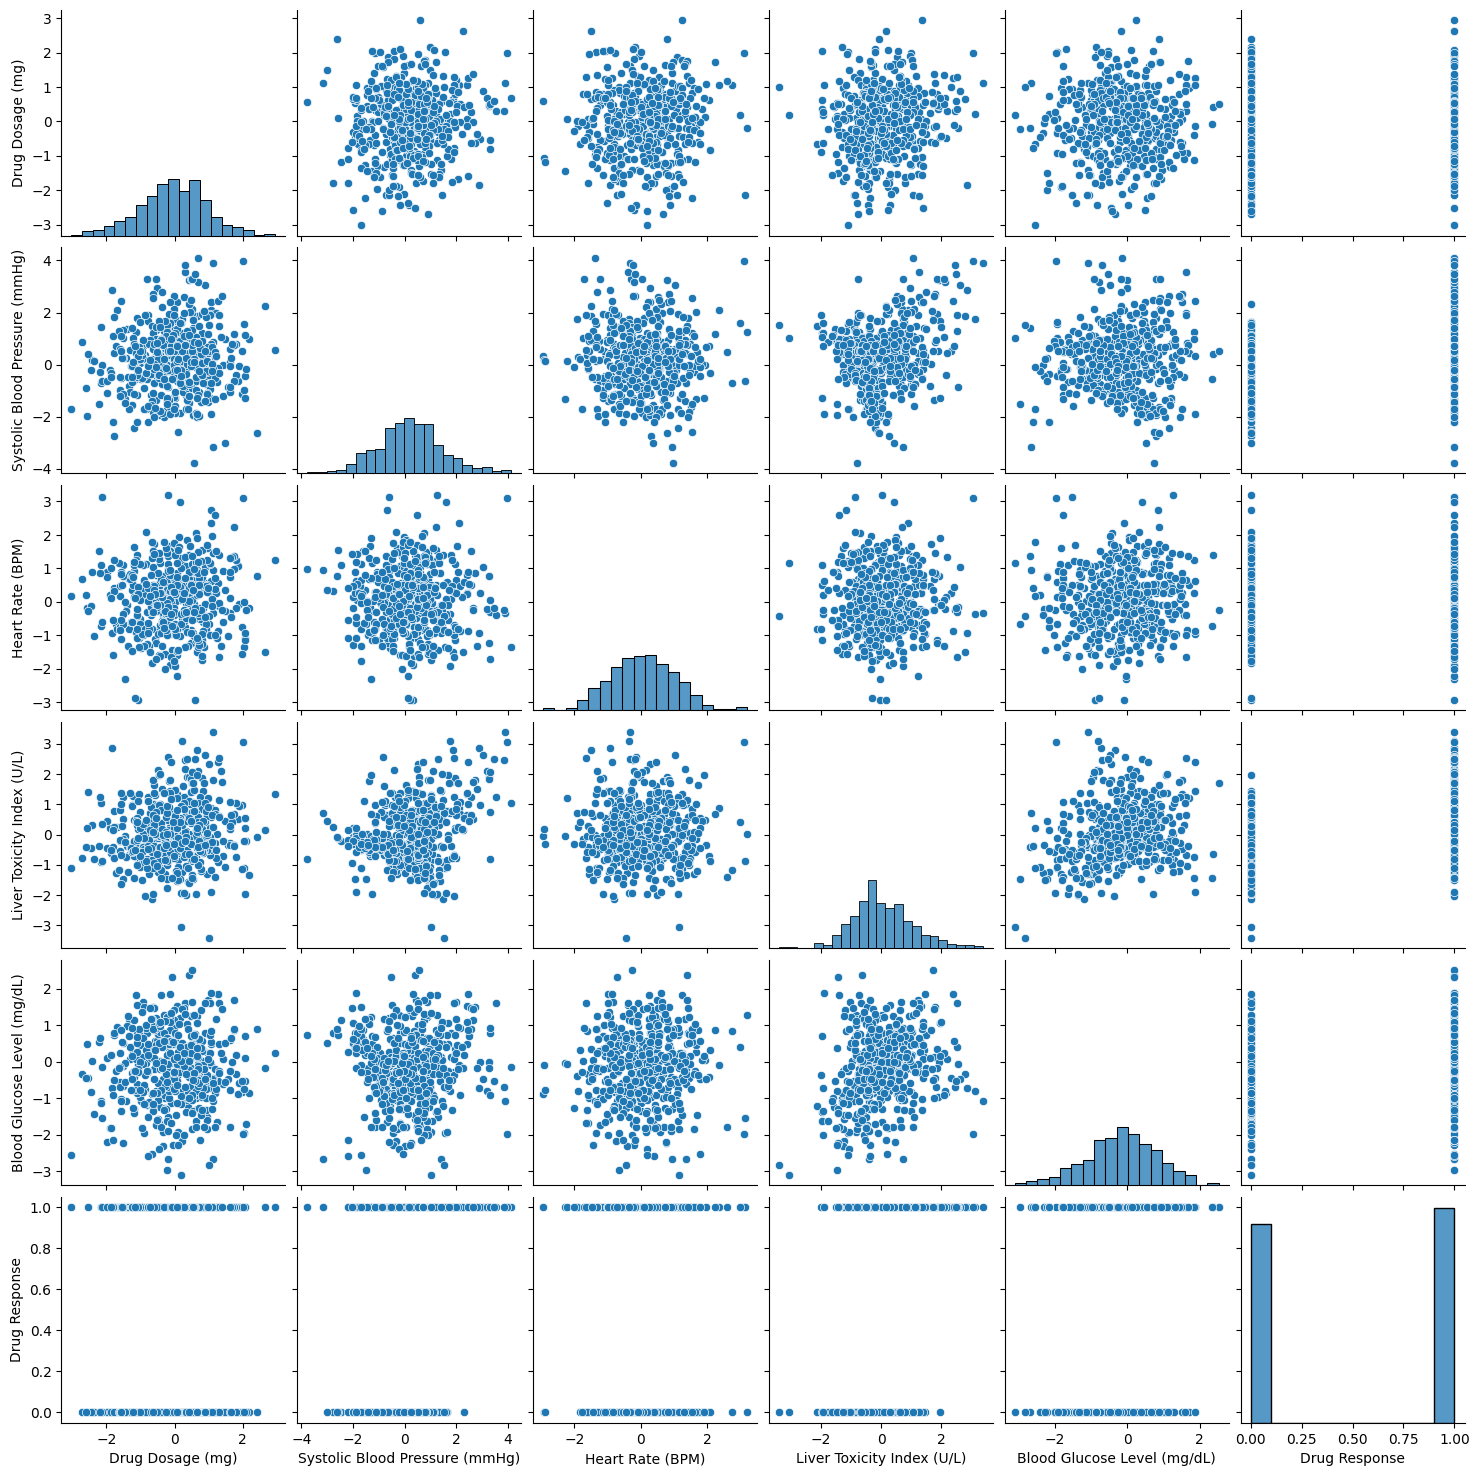

In [40]:
#  3. Pairplot to visualize relationships between features
sns.pairplot(df)
plt.show()

In [45]:
# Split the dataset into training and testing sets.
from sklearn.model_selection import train_test_split
X = df.drop('Drug Response', axis=1)
y = df['Drug Response']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


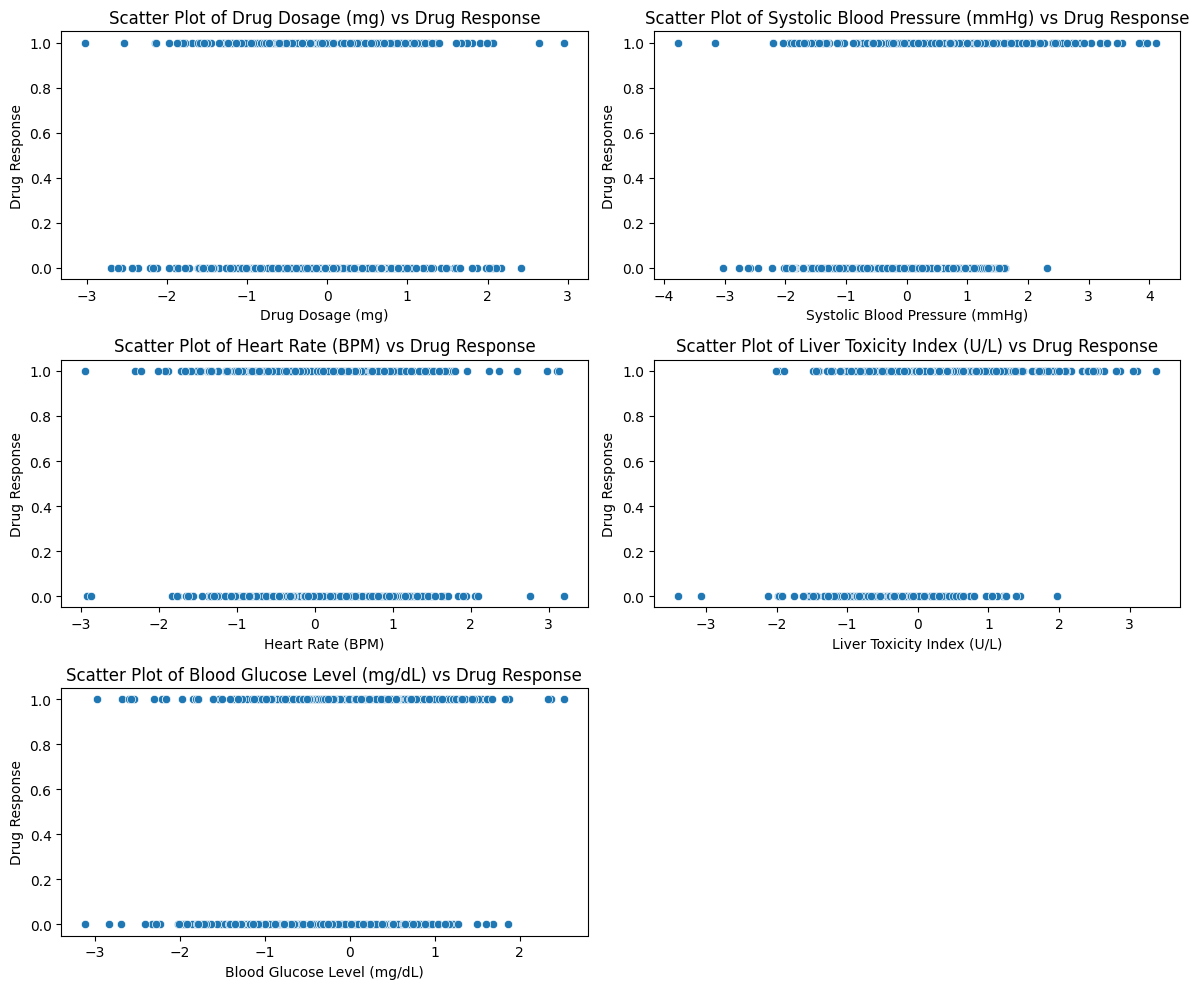

In [48]:
# 1.	Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships
# columns - Drug Dosage (mg)	Systolic Blood Pressure (mmHg)	Heart Rate (BPM)	Liver Toxicity Index (U/L)	Blood Glucose Level (mg/dL)	Drug Response
import matplotlib.pyplot as plt
import seaborn as sns
# Scatter plots for each feature against the target variable
plt.figure(figsize=(12, 10))
for i, column in enumerate(X.columns):
    plt.subplot(3, 2, i + 1)
    sns.scatterplot(x=df[column], y=df['Drug Response'])
    plt.title(f'Scatter Plot of {column} vs Drug Response')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Class Distribution of Drug Response')

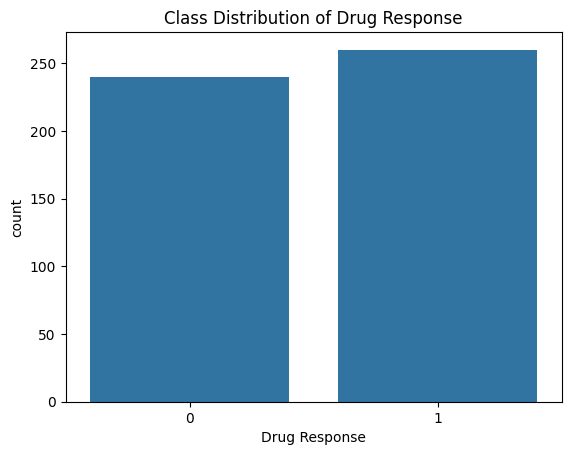

In [ ]:
# Visualize class distributions to gauge dataset balance or imbalance
sns.countplot(x=df['Drug Response'])
plt.title('Class Distribution of Drug Response')


In [50]:
# Implement a basic SVM classifier using Python libraries like scikit-learn
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# Train the SVM model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
# Make predictions
y_pred = svm_model.predict(X_test)
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))


Confusion Matrix:
[[36  8]
 [14 42]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.82      0.77        44
           1       0.84      0.75      0.79        56

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100

Accuracy Score: 0.78


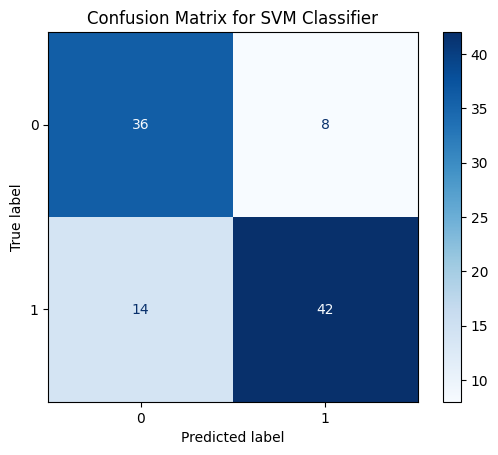

In [51]:
# Visualize classification results on the testing data
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(svm_model, X_test, y_test, cmap='Blues')
plt.title('Confusion Matrix for SVM Classifier')
plt.show()

In [ ]:
# Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance
# Define parameter grid for hyperparameter tuning
from sklearn.model_selection import GridSearchCV


param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

# Create a GridSearchCV object
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy')

# Fit the grid search on training data
grid_search.fit(X_train, y_train)

# Print best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Score:", grid_search.best_score_)

Best Parameters: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
Best Cross-validation Score: 0.74


In [54]:
# 1.	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).
kernels = ['linear', 'poly', 'rbf']
for kernel in kernels:
    model = SVC(kernel=kernel, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Kernel: {kernel}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Accuracy Score:", accuracy_score(y_test, y_pred))
    print("-" * 50)


Kernel: linear
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.82      0.77        44
           1       0.84      0.75      0.79        56

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100

Accuracy Score: 0.78
--------------------------------------------------
Kernel: poly
Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.89      0.72        44
           1       0.86      0.54      0.66        56

    accuracy                           0.69       100
   macro avg       0.73      0.71      0.69       100
weighted avg       0.74      0.69      0.68       100

Accuracy Score: 0.69
--------------------------------------------------
Kernel: rbf
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.84     

In [ ]:
# 2.	Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.
# Based on the EDA and visualizations, we can analyze the strengths and weaknesses of SVM for this dataset:
# Strengths:
# 1. SVM can effectively handle high-dimensional data, which is beneficial if the dataset has many features.
# 2. SVM is robust to outliers, especially when using a non-linear kernel, which can help in cases where the data is not perfectly clean.
# 3. SVM can capture complex relationships between features and the target variable, especially with non-linear kernels like RBF or polynomial.
# Weaknesses:
# 1. SVM can be sensitive to the choice of kernel and hyperparameters, which may require extensive tuning to achieve optimal performance.
# 2. SVM may not perform well on very large datasets due to its computational complexity

# 3.	Discuss practical implications of SVM in real-world classification tasks
# SVM is widely used in real-world classification tasks due to its effectiveness in handling high-dimensional data and its ability to model complex relationships. However, practitioners should be mindful of the need for careful hyperparameter tuning and the potential computational challenges when working with large datasets. SVM can be particularly useful in applications such as image classification, text categorization, and bioinformatics, where the data may have many features and complex patterns.
